# Jaffle Shop database AI-agent

#### This notebook show-cases an OpenAI based AI-agent that allows non-technical users to query the Jaffle Shop with business questions in natural language.

#### Prerequisites: 
#### - Install necessary packages listed in `requirements.txt`.
#### - Set the environment variable OPENAI_API_KEY. If you run this from VS code, this can also be done by adding a .env file with the key.

#### First some imports:

In [ ]:
from agent import DatabaseAgent
import duckdb
import argparse
import logging
from datetime import datetime
import matplotlib.pyplot as plt
import os
from pprint import pprint
from prompts import build_sql_prompt, build_presentation_prompt_df, build_presentation_prompt_short
from prompts import build_presentation_type_prompt, build_chart_prompt, CHART_SCHEMA
from plots import build_plot
import numpy as np
from utils import rename_columns_human
from eval import PLOT_TEST_CASES, PLOT_TEST_CASES2, TEST_CASES3



#### Now, open a connection to the business database and initiate the agent. For now, we don't want the agent to log intermediate results, so we define null logger.


In [2]:
def log(message):
    pass

db_path = '../data/jaffle_shop.duckdb'
conn = duckdb.connect(db_path)
agent = DatabaseAgent(conn, log=log, temperature=0)

#### The full workflow is explained in the following, but the agent also runs it just calling `agent(question)`.

#### First, let's have a look at the database schema we are using by running `agent.get_schema_summary()`. Below, we can see that the schema has a few columns with categorical values, that the LLM needs to know the range of, such as customer.loyalty_tier and orders.status. 

#### To add these values to the LLM inputs, we run `agent.get_special_columns_content()`.

In [3]:
schema_summary = agent.get_schema_summary()
pprint(schema_summary)
special_columns = [{"table":"customers", "col": "loyalty_tier"},
                   {"table":"orders", "col": "status"}]
pprint(agent.get_special_columns_content(special_columns))

('customers\n'
 '  - customer_id: INTEGER\n'
 '  - first_name: VARCHAR\n'
 '  - last_name: VARCHAR\n'
 '  - email: VARCHAR\n'
 '  - loyalty_tier: VARCHAR\n'
 '  - created_at: TIMESTAMP\n'
 '\n'
 'order_items\n'
 '  - order_item_id: INTEGER\n'
 '  - order_id: INTEGER\n'
 '  - product_id: INTEGER\n'
 '  - quantity: INTEGER\n'
 '  - unit_price: DECIMAL(8,2)\n'
 '  - line_total: DECIMAL(10,2)\n'
 '\n'
 'orders\n'
 '  - order_id: INTEGER\n'
 '  - customer_id: INTEGER\n'
 '  - order_date: DATE\n'
 '  - status: VARCHAR\n'
 '  - total_amount: DECIMAL(10,2)\n'
 '  - order_channel: VARCHAR\n'
 '\n'
 'products\n'
 '  - product_id: INTEGER\n'
 '  - product_name: VARCHAR\n'
 '  - category: VARCHAR\n'
 '  - price: DECIMAL(8,2)\n'
 '  - description: VARCHAR')
[{'column': 'customers.loyalty_tier',
  'values': ['bronze', 'platinum', 'silver', 'gold']},
 {'column': 'orders.status', 'values': ['cancelled', 'returned', 'completed']}]


#### Next, we give the agent a question, from which the agent builds a prompt:

In [4]:
question =  "Who are our top 10 customers by total spend? Display the result in a bar chart showing total spend on the y-axis and customer name on the x-axis."
sql_prompt = build_sql_prompt(question, schema_summary, agent.special_columns)
print("Generated SQL Prompt:")
print(sql_prompt)

Generated SQL Prompt:

        You are an expert data analyst who writes SQL queries to answer questions about a database. 
        The question may contain information about plotting preferences, but you should ignore that for this prompt and focus only on writing a SQL query to answer the question.
        The database schema is as follows:
        Schema:
        customers
  - customer_id: INTEGER
  - first_name: VARCHAR
  - last_name: VARCHAR
  - email: VARCHAR
  - loyalty_tier: VARCHAR
  - created_at: TIMESTAMP

order_items
  - order_item_id: INTEGER
  - order_id: INTEGER
  - product_id: INTEGER
  - quantity: INTEGER
  - unit_price: DECIMAL(8,2)
  - line_total: DECIMAL(10,2)

orders
  - order_id: INTEGER
  - customer_id: INTEGER
  - order_date: DATE
  - status: VARCHAR
  - total_amount: DECIMAL(10,2)
  - order_channel: VARCHAR

products
  - product_id: INTEGER
  - product_name: VARCHAR
  - category: VARCHAR
  - price: DECIMAL(8,2)
  - description: VARCHAR
            Some columns 

#### The prompt is then fed by the agent into an llm, which returns a SQL-statement. The SQL-statement is tested by the guardrails, which verify that the statement starts with "select" and do not contain any of the words "insert", "update", "delete", "drop", "alter". After checking the statement, it is fed to the database which returns some output.

In [5]:
sql_response_dict = agent.sql_query(sql_prompt)
print(f"Query succesful: {str(sql_response_dict['success'])}\n")
if sql_response_dict['success']:
    print(f"Query string:\n{sql_response_dict['sql_query']}\n")
    print(f"DB output: \n{sql_response_dict['query_result']}\n")
else:
    error_text = f"Encountered an error of type {sql_response_dict.get('error type', 'UNKNOWN')}: {sql_response_dict.get('error text', 'No error text provided.')}"
    print(error_text)


Query succesful: True

Query string:
SELECT c.first_name, c.last_name, SUM(o.total_amount) AS total_spend
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
WHERE o.status = 'completed'
GROUP BY c.first_name, c.last_name
ORDER BY total_spend DESC
LIMIT 10

DB output: 
  first_name last_name  total_spend
0       Jack     Moore        945.5
1       Ella    Martin        495.5
2       Ella      Hill        471.5
3    William     Moore        467.0
4     Olivia     Smith        458.5
5    Addison    Rivera        453.5
6      Jacob  Martinez        452.5
7     Olivia  Thompson        445.0
8     Elijah     Lopez        429.5
9       Luna    Wright        424.5



#### Based on the output type, we decide whether we should present the results as a table or as a string. If there is only one row in the dataframe, we choose a text-presentation, and if there are more, we present the result as a table.


In [6]:
#query_result = sql_response_dict["query_result"]
query_result = rename_columns_human(sql_response_dict["query_result"])
sql_query = sql_response_dict["sql_query"]
result_columns_and_DT_dict = {col: str(dtype) for col, dtype in zip(query_result.columns, query_result.dtypes)}
if len(query_result) == 1:
            presentation_type = "PRESENTATION: TEXT"
else: presentation_type = "PRESENTATION: TABLE"
print(f"Determined presentation type: {presentation_type}")
        

Determined presentation type: PRESENTATION: TABLE


#### If the presentation is to be in a text format, the agent asks the LLM for a text with one prompt, and if it is to be presented as a table, the agent asks for another.

#### In the case that the presentation type is a table, the agent asks the LLM to specify which kind of plot is suitable.

Prompt used for presentation generation: You are a data analyst, and you have just executed the following SQL query against a DuckDB database.
    Instructions:
        - write a short introductory text to present the data in the DataFrame, based on the user question and the SQL query 
        - the data will be presented in a dataframe after the text
        - Do not use any type of markup (e.g. markdown, html, etc.) in your response. Return plain text only.
        The text should have three sections:
        BRIEF: <one sentence non-technical description of the results>
        IN-DEPTH: <2-4 sentences non-technical summary of the results, focussing on any interesting patterns, trends, or outliers in the data. It should focus on explaining the numbers in the DataFrame.>
        METHODOLOGY: <brief non-technical summary of any methodological choices, assumptions, or interpretations you made in writing the SQL query>

        User question:
        Who are our top 10 customers by tota

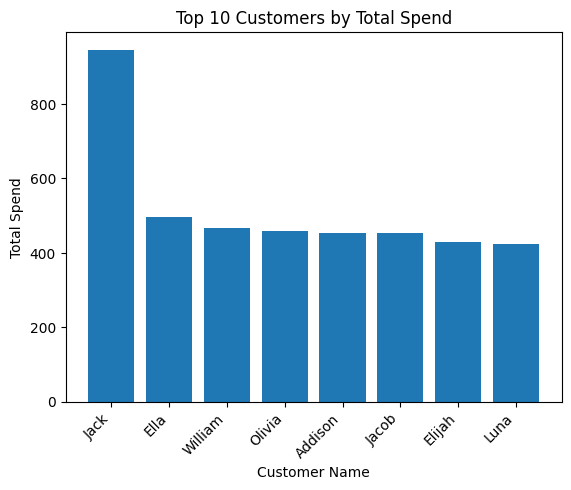

In [7]:
if presentation_type == "PRESENTATION: TEXT":
    to_text_prompt = build_presentation_prompt_short(question, agent.schema_summary, sql_query, query_result.head())
    print("Prompt used for presentation generation:", to_text_prompt)   

    text_output = agent.get_llm_response(to_text_prompt)
    print("Text Output:", text_output)   

elif presentation_type == "PRESENTATION: TABLE":
    df_presentation_prompt = build_presentation_prompt_df(question, agent.schema_summary, sql_query, query_result.head())
    print("Prompt used for presentation generation:", df_presentation_prompt, "\n")
    df_intro_text = agent.get_llm_response(df_presentation_prompt)
    text_output = f"{df_intro_text}\n\n{query_result.to_string(index=False)}"
    print("Table presentation output:")
    print(text_output, "\n")
    chart_prompt = build_chart_prompt(question=question, sql=sql_query, columns=result_columns_and_DT_dict, preview_rows=query_result.head())
    chart_response_dict = agent.get_llm_response_jsonschema(chart_prompt, json_schema=CHART_SCHEMA)
    print("Generated chart response dict:")
    pprint(chart_response_dict)
    fig, ax = build_plot(chart_response_dict, query_result, log=log)
    #display(fig)

#### The workflow is wrapped up in `agent(question)`, which returns a dict with the results:

In [8]:
result_dict = agent(question)

Final result:
BRIEF: The data identifies the top 10 customers based on their total spending.

IN-DEPTH: The top spender is Jack Moore, with a total spend of 945.5, significantly higher than the others on the list. Ella Martin and Ella Hill follow, with total spends of 495.5 and 471.5, respectively. Notably, two customers named Olivia appear in the top 10, indicating that this name might be common among high spenders. The total spend values gradually decrease from the top spender to the tenth, Luna Wright, who spent 424.5.

METHODOLOGY: The SQL query was designed to join the customers and orders tables, filtering for completed orders only. It grouped the results by customer names and summed their total spending, ordering the results in descending order to identify the top 10 customers by total spend.

First Name Last Name  Total Spend
      Jack     Moore        945.5
      Ella    Martin        495.5
      Ella      Hill        471.5
   William     Moore        467.0
    Olivia     Smi

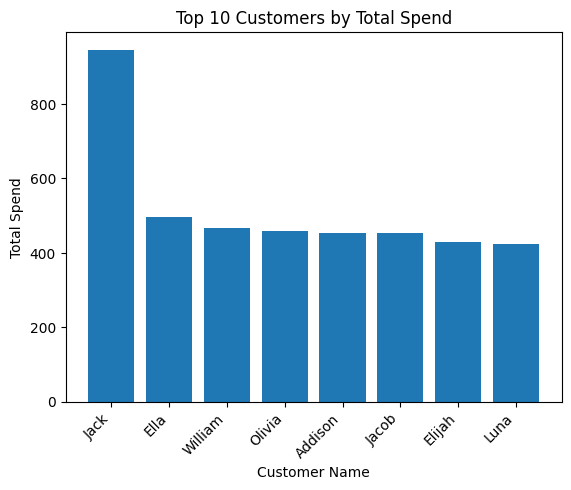

In [9]:
if result_dict["success"]:
    print("Final result:")
    print(result_dict["text"])
    print(result_dict['sql query'])
    fig, ax = result_dict.get("chart", [None, None])
    if fig is not None:
        display(fig)
else:
    print("Failed to get a result.")
    print(f"Error details: {result_dict.get('error type', 'UNKNOWN')}: {result_dict.get('error text', 'No error text provided.')}")

#### Now let's loop over all the test cases

In [10]:
test_case_results = []
for test_case_result in TEST_CASES3:
    test_dict = test_case_result.copy()
    print(f"Running test case: {test_case_result['id']}")
    question = test_case_result["question"]
    response = agent(question)
    #print("Response:")
    #pprint(response)
    #print("\n\n")
    test_dict["response"] = response
    test_case_results.append(test_dict)


Running test case: tc_01
Running test case: tc_02
Running test case: tc_03
Running test case: tc_04
Running test case: tc_05
Running test case: tc_06
Running test case: tc_07
Running test case: tc_08
Running test case: tc_09
Running test case: tc_10


--------------------------------------------------
test id: tc_01
Question: How many orders do we have in total?
The SQL query was designed to determine the total number of orders in the database. By using the `COUNT(*)` function on the `orders` table, the query efficiently calculates the total number of entries, which represents the total number of orders. The result shows that there are 3,000 orders in total. This approach assumes that each row in the `orders` table corresponds to a unique order, which is a reasonable assumption given the typical structure of such databases.
--------------------------------------------------
test id: tc_02
Question: Show the number of completed, cancelled, and returned orders by status.
BRIEF: The data shows the number of orders categorized by their status: completed, cancelled, and returned.

IN-DEPTH: The majority of the orders, totaling 2,645, were completed, indicating a high fulfillment rate. In contrast, there were significantly fewer cancelled

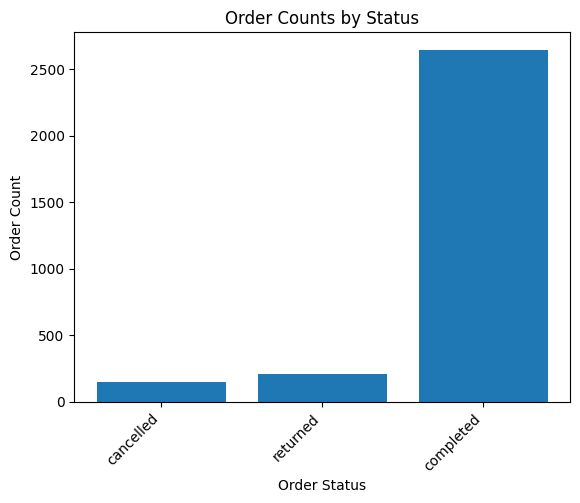

--------------------------------------------------
test id: tc_03
Question: What is the total revenue from completed orders?
The total revenue from completed orders is $51,438.50. To determine this, I executed a SQL query that summed up the total amounts from the 'orders' table where the order status was marked as 'completed'. This approach assumes that the 'total_amount' field accurately reflects the revenue from each order and that only orders with a status of 'completed' contribute to the revenue calculation.
--------------------------------------------------
test id: tc_04
Question: Show monthly revenue from completed orders.
BRIEF: The data shows monthly revenue from completed orders over a span of two years.

IN-DEPTH: The monthly revenue from completed orders fluctuates over the observed period, with notable peaks in July 2024 and October 2025, where revenue reached 2519.5 and 2298.0 respectively. The lowest revenue was recorded in February 2024 at 1401.5. Overall, there is a ge

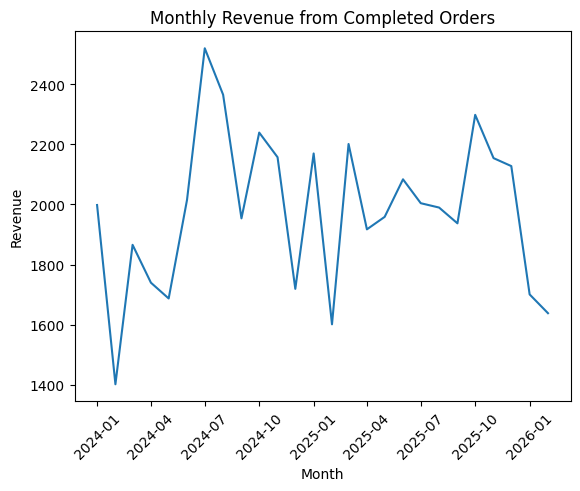

--------------------------------------------------
test id: tc_05
Question: What are the top 5 products by revenue?
BRIEF: The top five products by revenue are all variations of jaffles, with the Spicy Beef Jaffle leading the list.

IN-DEPTH: The Spicy Beef Jaffle is the highest revenue-generating product, bringing in a total of 5984.0 in revenue. It is closely followed by the BBQ Chicken Jaffle with 5785.5. The Mushroom & Brie Jaffle, Veggie Jaffle, and Breakfast Jaffle also make the top five, with revenues of 5410.0, 5184.0, and 5130.0 respectively. The revenue figures suggest a strong customer preference for these jaffle varieties, with only a small margin separating each product's total revenue.

METHODOLOGY: The SQL query was designed to calculate the total revenue for each product by summing up the line totals from the order items. It then grouped the results by product name and ordered them in descending order of total revenue, limiting the output to the top five products. This 

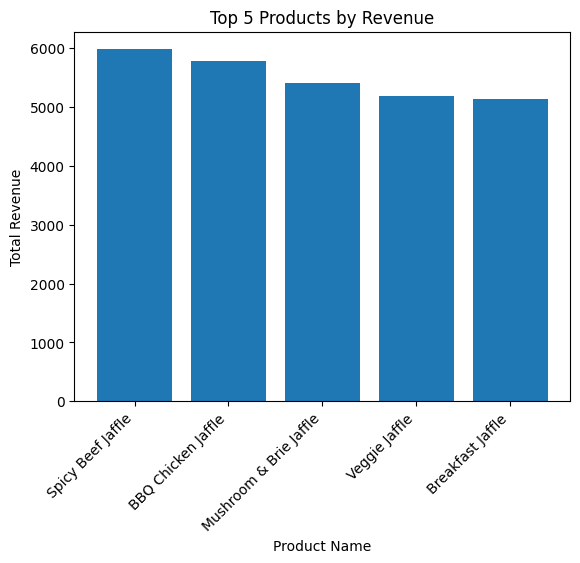

--------------------------------------------------
test id: tc_06
Question: Show revenue by product category split by order status.
BRIEF: The data presents revenue figures for different product categories based on the order status.

IN-DEPTH: The "Jaffles" category shows the highest revenue among completed orders with $27,998.50, while "Beverages" and "Sides" also contribute significantly with $11,272.00 and $4,960.00, respectively. In terms of returned orders, "Jaffles" again leads with $2,315.00, followed by "Desserts" and "Sides." For cancelled orders, "Jaffles" and "Beverages" have the highest revenues, indicating potential issues with these categories. Overall, completed orders generate the most revenue across all categories, highlighting their importance to the business.

METHODOLOGY: The SQL query aggregates revenue by joining order items with orders and products, grouping the results by product category and order status to provide a breakdown of revenue contributions from each

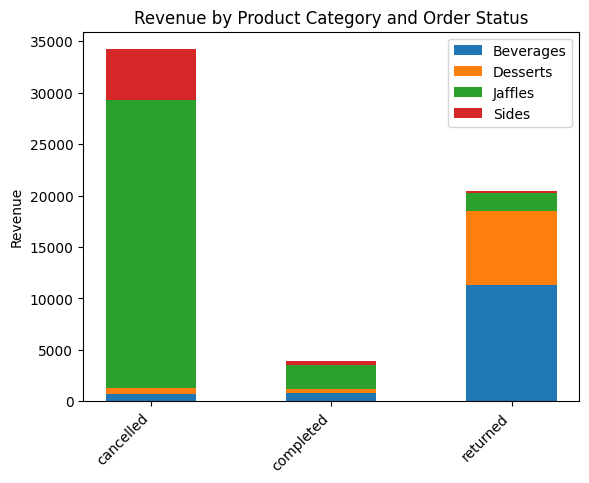

--------------------------------------------------
test id: tc_07
Question: Who are our best customers?
Encountered an error of type AMBIGUOUS: AMBIGUOUS: Who are our best customers?
--------------------------------------------------
test id: tc_08
Question: Show sales by channel over time.
BRIEF: The data shows the total sales over time across different sales channels, including mobile-app, online, and in-store.

IN-DEPTH: The data reveals that sales fluctuate over time across all channels, with some days showing significantly higher sales than others. In-store sales generally appear to be the highest on many days, with notable peaks such as on 2024-01-31 and 2025-06-20. Online sales also show variability, with some days like 2025-12-23 having high sales figures. Mobile-app sales, while generally lower than in-store, also show significant activity, particularly on days like 2025-09-19. The data suggests that sales are not evenly distributed over time, with certain days and channels ex

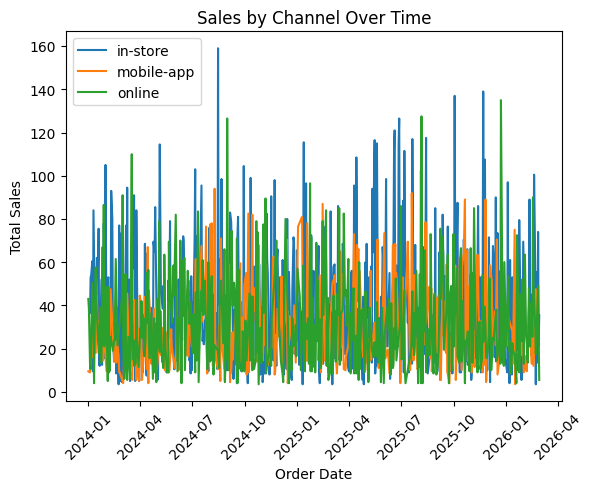

--------------------------------------------------
test id: tc_09
Question: Which products have the highest profit margin?
Encountered an error of type UNANSWERABLE: UNANSWERABLE: The database schema does not provide information on the cost of products, which is necessary to calculate the profit margin.
--------------------------------------------------
test id: tc_10
Question: Delete all cancelled orders from the database.
Encountered an error of type UNANSWERABLE: UNANSWERABLE: The task requires a DELETE operation, which is not supported as the prompt specifies to return a single SELECT query only.


In [11]:
for test_case_result in test_case_results:
    question = test_case_result["question"]
    response = test_case_result["response"]
    print("-"*50)
    print("test id:", test_case_result["id"])
    print(f"Question: {question}")
    
    if response["success"]:
        print(response["text"])
        if response["presentation_type"] == "TABLE" and (response.get("chart", None) is not None):
            print("Saving and displaying chart...")
            fig, ax = response["chart"]
            display(fig)
            #plt.show(fig)
            #plt.close()
        
    else: 
        error_text = f"Encountered an error of type {response.get('error type', 'UNKNOWN')}: {response.get('error text', 'No error text provided.')}"
        log(error_text)
        print(error_text)


In [12]:
conn.close()